# Week1: EDA & TEDS Preparation  
Goal: Analyze header structure distributions and prepare TEDS evaluation functions.  

Part 1: Html EDA  
Part 2: Image EDA  
Part 3: Merge image-level features with HTML structural features  
Part 4: TEDS (Tree-Edit-Distance) calculation  

- What is the structure of the table (number of rows, number of columns)?
- Is there any complex structure (colspan / rowspan)?
- Which samples are "difficult cases" (hard examples)?

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# confirm the path
import os

base_path = "/content/drive/MyDrive/cv project"
os.listdir(base_path)

['hierarchical_tables_v1.zip',
 'hierarchical_tables_v1',
 'week1_eda+teds.html',
 'week1_eda+teds.ipynb',
 'week2_html parsing function.ipynb',
 'parsed_sample_0.csv']

In [ ]:
# unzip data
import zipfile

zip_path = "/content/drive/MyDrive/cv project/hierarchical_tables_v1.zip"
extract_path = "/content/drive/MyDrive/cv project/hierarchical_tables_v1"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped!")

In [10]:
os.listdir("/content/drive/MyDrive/cv project/hierarchical_tables_v1")

['data']

In [11]:
# define base path
BASE_PATH = "/content/drive/MyDrive/cv project/hierarchical_tables_v1/data/processed"

IMAGE_DIR = BASE_PATH + "/images"
JSONL_PATH = BASE_PATH + "/hard_examples_subset.jsonl"

In [12]:
# read jsonl: data structure
import json

records = []

with open(JSONL_PATH, "r", encoding="utf-8") as f:
    for line in f:
        records.append(json.loads(line))

print("Total records:", len(records))
records[0]

Total records: 32670


{'html_table': '<table>\n <tr>\n  <td>\n  </td>\n  <td colspan="3">\n   Year Ended\n  </td>\n </tr>\n <tr>\n  <td>\n  </td>\n  <td>\n   December 31, 2017\n  </td>\n  <td>\n   December 31, 2016\n  </td>\n  <td>\n   December 31, 2015\n  </td>\n </tr>\n <tr>\n  <td>\n   Development projects:\n  </td>\n  <td>\n  </td>\n  <td>\n  </td>\n  <td>\n  </td>\n </tr>\n <tr>\n  <td>\n   Triple-net\n  </td>\n  <td>\n   $283,472\n  </td>\n  <td>\n   $46,094\n  </td>\n  <td>\n   $104,844\n  </td>\n </tr>\n <tr>\n  <td>\n   Seniors housing operating\n  </td>\n  <td>\n   3,634\n  </td>\n  <td>\n   18,979\n  </td>\n  <td>\n   19,869\n  </td>\n </tr>\n <tr>\n  <td>\n   Outpatient medical\n  </td>\n  <td>\n   63,036\n  </td>\n  <td>\n   108,001\n  </td>\n  <td>\n   16,592\n  </td>\n </tr>\n <tr>\n  <td>\n   Total development projects\n  </td>\n  <td>\n   350,142\n  </td>\n  <td>\n   173,074\n  </td>\n  <td>\n   141,305\n  </td>\n </tr>\n <tr>\n  <td>\n   Expansion projects\n  </td>\n  <td>\n   10,336\n  </

<table>
 <tr>
  <td>
  </td>
  <td colspan="3">
   Year Ended
  </td>
 </tr>
 <tr>
  <td>
  </td>
  <td>
   December 31, 2017
  </td>
  <td>
   December 31, 2016
  </td>
  <td>
   December 31, 2015
  </td>
 </tr>
 <tr>
  <td>
   Development projects:
  </td>
  <td>
  </td>
  <td>
  </td>
  <td>
  </td>
 </tr>
 <tr>
  <td>
   Triple-net
  </td>
  <td>
   $283,472
  </td>
  <td>
   $46,094
  </td>
  <td>
   $104,844
  </td>
 </tr>
 <tr>
  <td>
   Seniors housing operating
  </td>
  <td>
   3,634
  </td>
  <td>
   18,979
  </td>
  <td>
   19,869
  </td>
 </tr>
 <tr>
  <td>
   Outpatient medical
  </td>
  <td>
   63,036
  </td>
  <td>
   108,001
  </td>
  <td>
   16,592
  </td>
 </tr>
 <tr>
  <td>
   Total development projects
  </td>
  <td>
   350,142
  </td>
  <td>
   173,074
  </td>
  <td>
   141,305
  </td>
 </tr>
 <tr>
  <td>
   Expansion projects
  </td>
  <td>
   10,336
  </td>
  <td>
   11,363
  </td>
  <td>
   38,808
  </td>
 </tr>
 <tr>
  <td>
   Total construction in progress co

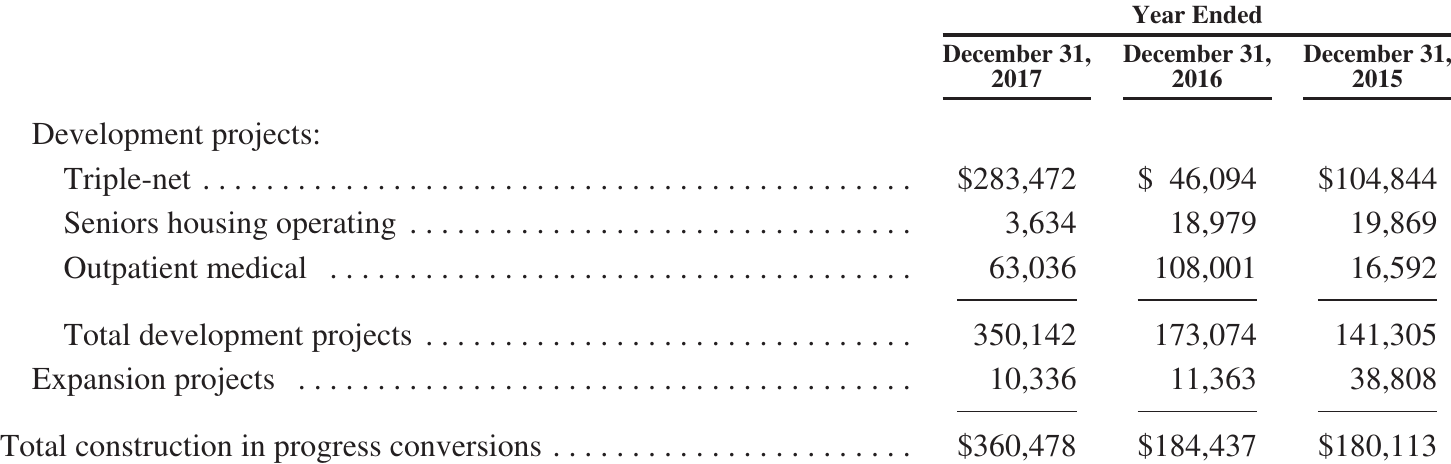

In [13]:
# show data format: HTML and image mapping
from PIL import Image
import os

sample = records[0]

img_path = IMAGE_DIR + "/" + sample["imgid"] + ".png"

img = Image.open(img_path)
print(sample["html_table"])
img

# EDA part1: HTML

## 1. Parse HTML (Core function)  
Extract the HTML table structure: number of rows, number of columns, number of cells, presence of row and column crossing

In [14]:
from bs4 import BeautifulSoup

def extract_features(html):
    soup = BeautifulSoup(html, "html.parser")

    cells = soup.find_all(["td", "th"])
    rows = soup.find_all("tr")

    colspan_list = []
    rowspan_list = []

    for cell in cells:
        colspan = int(cell.get("colspan", 1))
        rowspan = int(cell.get("rowspan", 1))
        colspan_list.append(colspan)
        rowspan_list.append(rowspan)

    return {
        "num_rows": len(rows),
        "num_cells": len(cells),
        "max_colspan": max(colspan_list) if colspan_list else 1, #maximum span column
        "max_rowspan": max(rowspan_list) if rowspan_list else 1, #maximun span row
        "has_colspan": any(c > 1 for c in colspan_list),
        "has_rowspan": any(r > 1 for r in rowspan_list),
    }

## 2. Apply to all data

In [15]:
import pandas as pd

feature_list = []

for record in records:
    html = record["html_table"]
    features = extract_features(html)
    feature_list.append(features)

df_features = pd.DataFrame(feature_list)
df_features.head()

,num_rows,num_cells,max_colspan,max_rowspan,has_colspan,has_rowspan
0,9,34,3,1,True,False
1,40,158,3,1,True,False
2,6,55,2,2,True,True
3,7,26,3,1,True,False
4,12,46,2,2,True,True


- Most of the tables are regular tables, which have small rowspan/colspan values  
- A small portion of tables contains large colspan or rowspan values, suggesting more complex layouts.

# 3. colspan distribution  
The distribution of max_colspan (how many columns each table spans at most)  
The larger the colspan, the more likely the header is to be a multi-level structure

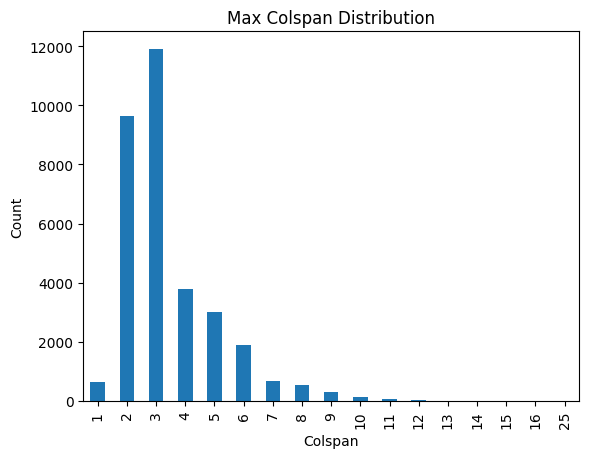

             count     ratio
max_colspan                 
1              627  0.019192
2             9653  0.295470
3            11908  0.364493
4             3801  0.116345
5             3023  0.092531
6             1896  0.058035
7              677  0.020722
8              551  0.016866
9              298  0.009122
10             131  0.004010
11              53  0.001622
12              44  0.001347
13               2  0.000061
14               2  0.000061
15               1  0.000031
16               2  0.000061
25               1  0.000031


In [16]:
import matplotlib.pyplot as plt

df_features["max_colspan"].value_counts().sort_index().plot(kind="bar")
plt.title("Max Colspan Distribution")
plt.xlabel("Colspan")
plt.ylabel("Count")
plt.show()


colspan_counts = df_features['max_colspan'].value_counts().sort_index()
colspan_ratio = df_features['max_colspan'].value_counts(normalize=True).sort_index()
result = pd.DataFrame({
    'count': colspan_counts,
    'ratio': colspan_ratio
})

print(result)

# 4. rowspan distribution  
The distribution of max_rowspan (how many rows each table spans at most)

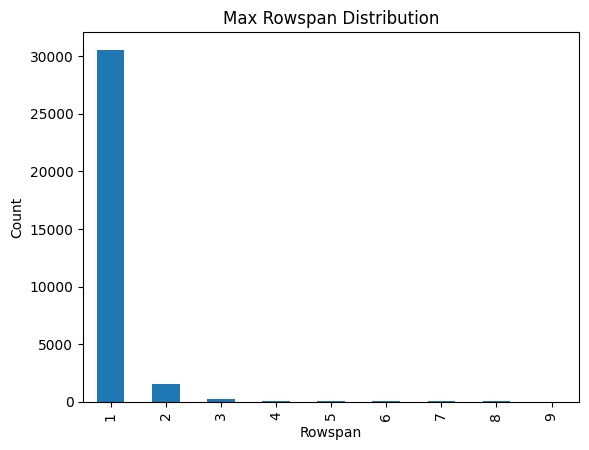

             count     ratio
max_rowspan                 
1            30533  0.934588
2             1559  0.047720
3              279  0.008540
4               86  0.002632
5               72  0.002204
6               49  0.001500
7               40  0.001224
8               39  0.001194
9               13  0.000398


In [17]:
df_features["max_rowspan"].value_counts().sort_index().plot(kind="bar")
plt.title("Max Rowspan Distribution")
plt.xlabel("Rowspan")
plt.ylabel("Count")
plt.show()

rowspan_counts = df_features['max_rowspan'].value_counts().sort_index()
rowspan_ratio = df_features['max_rowspan'].value_counts(normalize=True).sort_index()
result = pd.DataFrame({
    'count': rowspan_counts,
    'ratio': rowspan_ratio
})

print(result)

Most tables have low rowspan values, indicating that vertical merging is relatively limited. However, some tables still exhibit larger rowspan values, suggesting the presence of hierarchical row structures.

# 5. Simple vs. complex tables  
If there is colspan or rowspan → it is a complex table  
Otherwise → it is a simple table

In [18]:
df_features["is_complex"] = (
    df_features["has_colspan"] | df_features["has_rowspan"]
)

df_features["is_complex"].value_counts(normalize=True)

,proportion
is_complex,
True,1.0


# 6. Filter hard examples
Assign a "difficulty score" to each table

In [19]:
df_features["hard_score"] = (
    df_features["max_colspan"] * 2 +  # complexity of table headers
    df_features["max_rowspan"] * 2 +  # hierarchical complexity
    df_features["num_rows"] * 0.5 # Table size
)

hard_examples = df_features.sort_values("hard_score", ascending=False)

hard_examples.head(10)

,num_rows,num_cells,max_colspan,max_rowspan,has_colspan,has_rowspan,is_complex,hard_score
14650,10,236,25,1,True,False,True,57.0
32506,54,483,9,5,True,True,True,55.0
27077,69,680,9,1,True,False,True,54.5
31019,61,643,10,1,True,False,True,52.5
32485,63,668,5,5,True,True,True,51.5
3450,58,557,10,1,True,False,True,51.0
3512,58,554,10,1,True,False,True,51.0
30965,53,548,11,1,True,False,True,50.5
30633,51,602,11,1,True,False,True,49.5
30666,51,602,11,1,True,False,True,49.5


There are two types of hard tables:  
- **wide tables**  
  complex horizontal structure, header spans across many columns  
  -> difficult to predict the column structure
- **Large-scale dense table**  
  Large and complex, with multiple hierarchical structures  
  -> difficult to parse and recover structure

# 7. Linking Features to Images (Sample)

In [20]:
from PIL import Image
import os
import matplotlib.pyplot as plt

# attach image IDs to the feature DataFrame
df_features["imgid"] = [r["imgid"] for r in records]

# preview the DataFrame to confirm
df_features.head()

,num_rows,num_cells,max_colspan,max_rowspan,has_colspan,has_rowspan,is_complex,hard_score,imgid
0,9,34,3,1,True,False,True,12.5,fintabnet_000001
1,40,158,3,1,True,False,True,28.0,fintabnet_000004
2,6,55,2,2,True,True,True,11.0,fintabnet_000006
3,7,26,3,1,True,False,True,11.5,fintabnet_000007
4,12,46,2,2,True,True,True,14.0,fintabnet_000008


Image path: /content/drive/MyDrive/cv project/hierarchical_tables_v1/data/processed/images/fintabnet_000001.png
Image exists: True


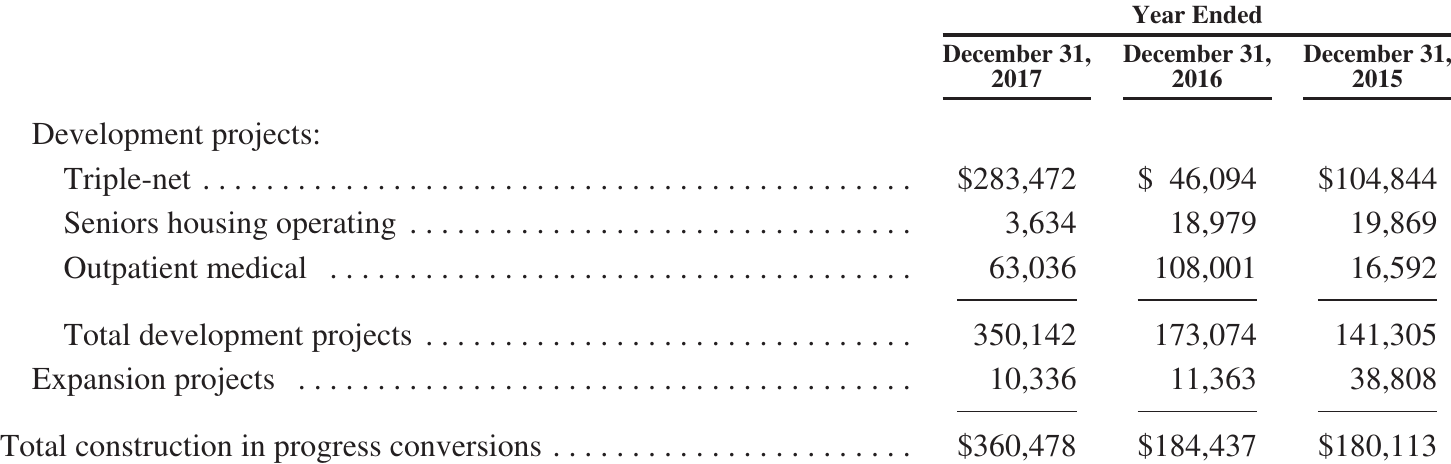

In [21]:
# display a sample image

sample = df_features.iloc[0]

img_path = os.path.join(IMAGE_DIR, sample["imgid"] + ".png")

print("Image path:", img_path)
print("Image exists:", os.path.exists(img_path))

img = Image.open(img_path)
img

Hardest example info:
num_rows                     10
num_cells                   236
max_colspan                  25
max_rowspan                   1
has_colspan                True
has_rowspan               False
is_complex                 True
hard_score                 57.0
imgid          fintabnet_027083
Name: 14650, dtype: object

Image path: /content/drive/MyDrive/cv project/hierarchical_tables_v1/data/processed/images/fintabnet_027083.png
Image exists: True


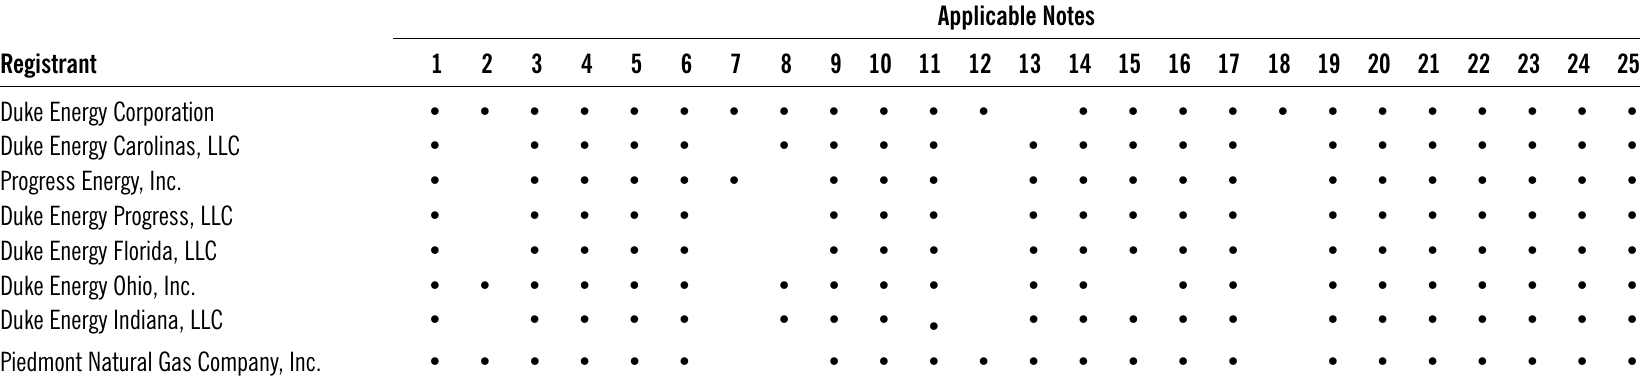

In [22]:
# identify and display the hardest example based on a heuristic score

df_features["hard_score"] = (
    df_features["max_colspan"] * 2
    + df_features["max_rowspan"] * 2
    + df_features["num_rows"] * 0.5
)

hard_examples = df_features.sort_values("hard_score", ascending=False)

hardest = hard_examples.iloc[0]

img_path = os.path.join(IMAGE_DIR, hardest["imgid"] + ".png")

print("Hardest example info:")
print(hardest)

print("\nImage path:", img_path)
print("Image exists:", os.path.exists(img_path))

Image.open(img_path)

Image ID: fintabnet_027083
Hard score: 57.0
Max colspan: 25
Max rowspan: 1
Number of rows: 10
Image exists: True


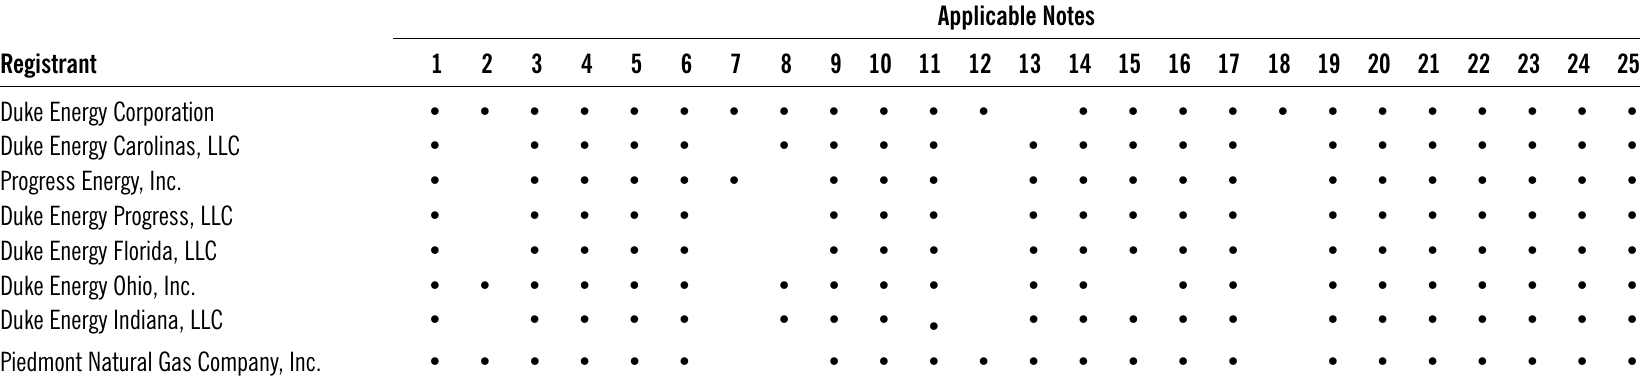

Image ID: fintabnet_061511
Hard score: 55.0
Max colspan: 9
Max rowspan: 5
Number of rows: 54
Image exists: True


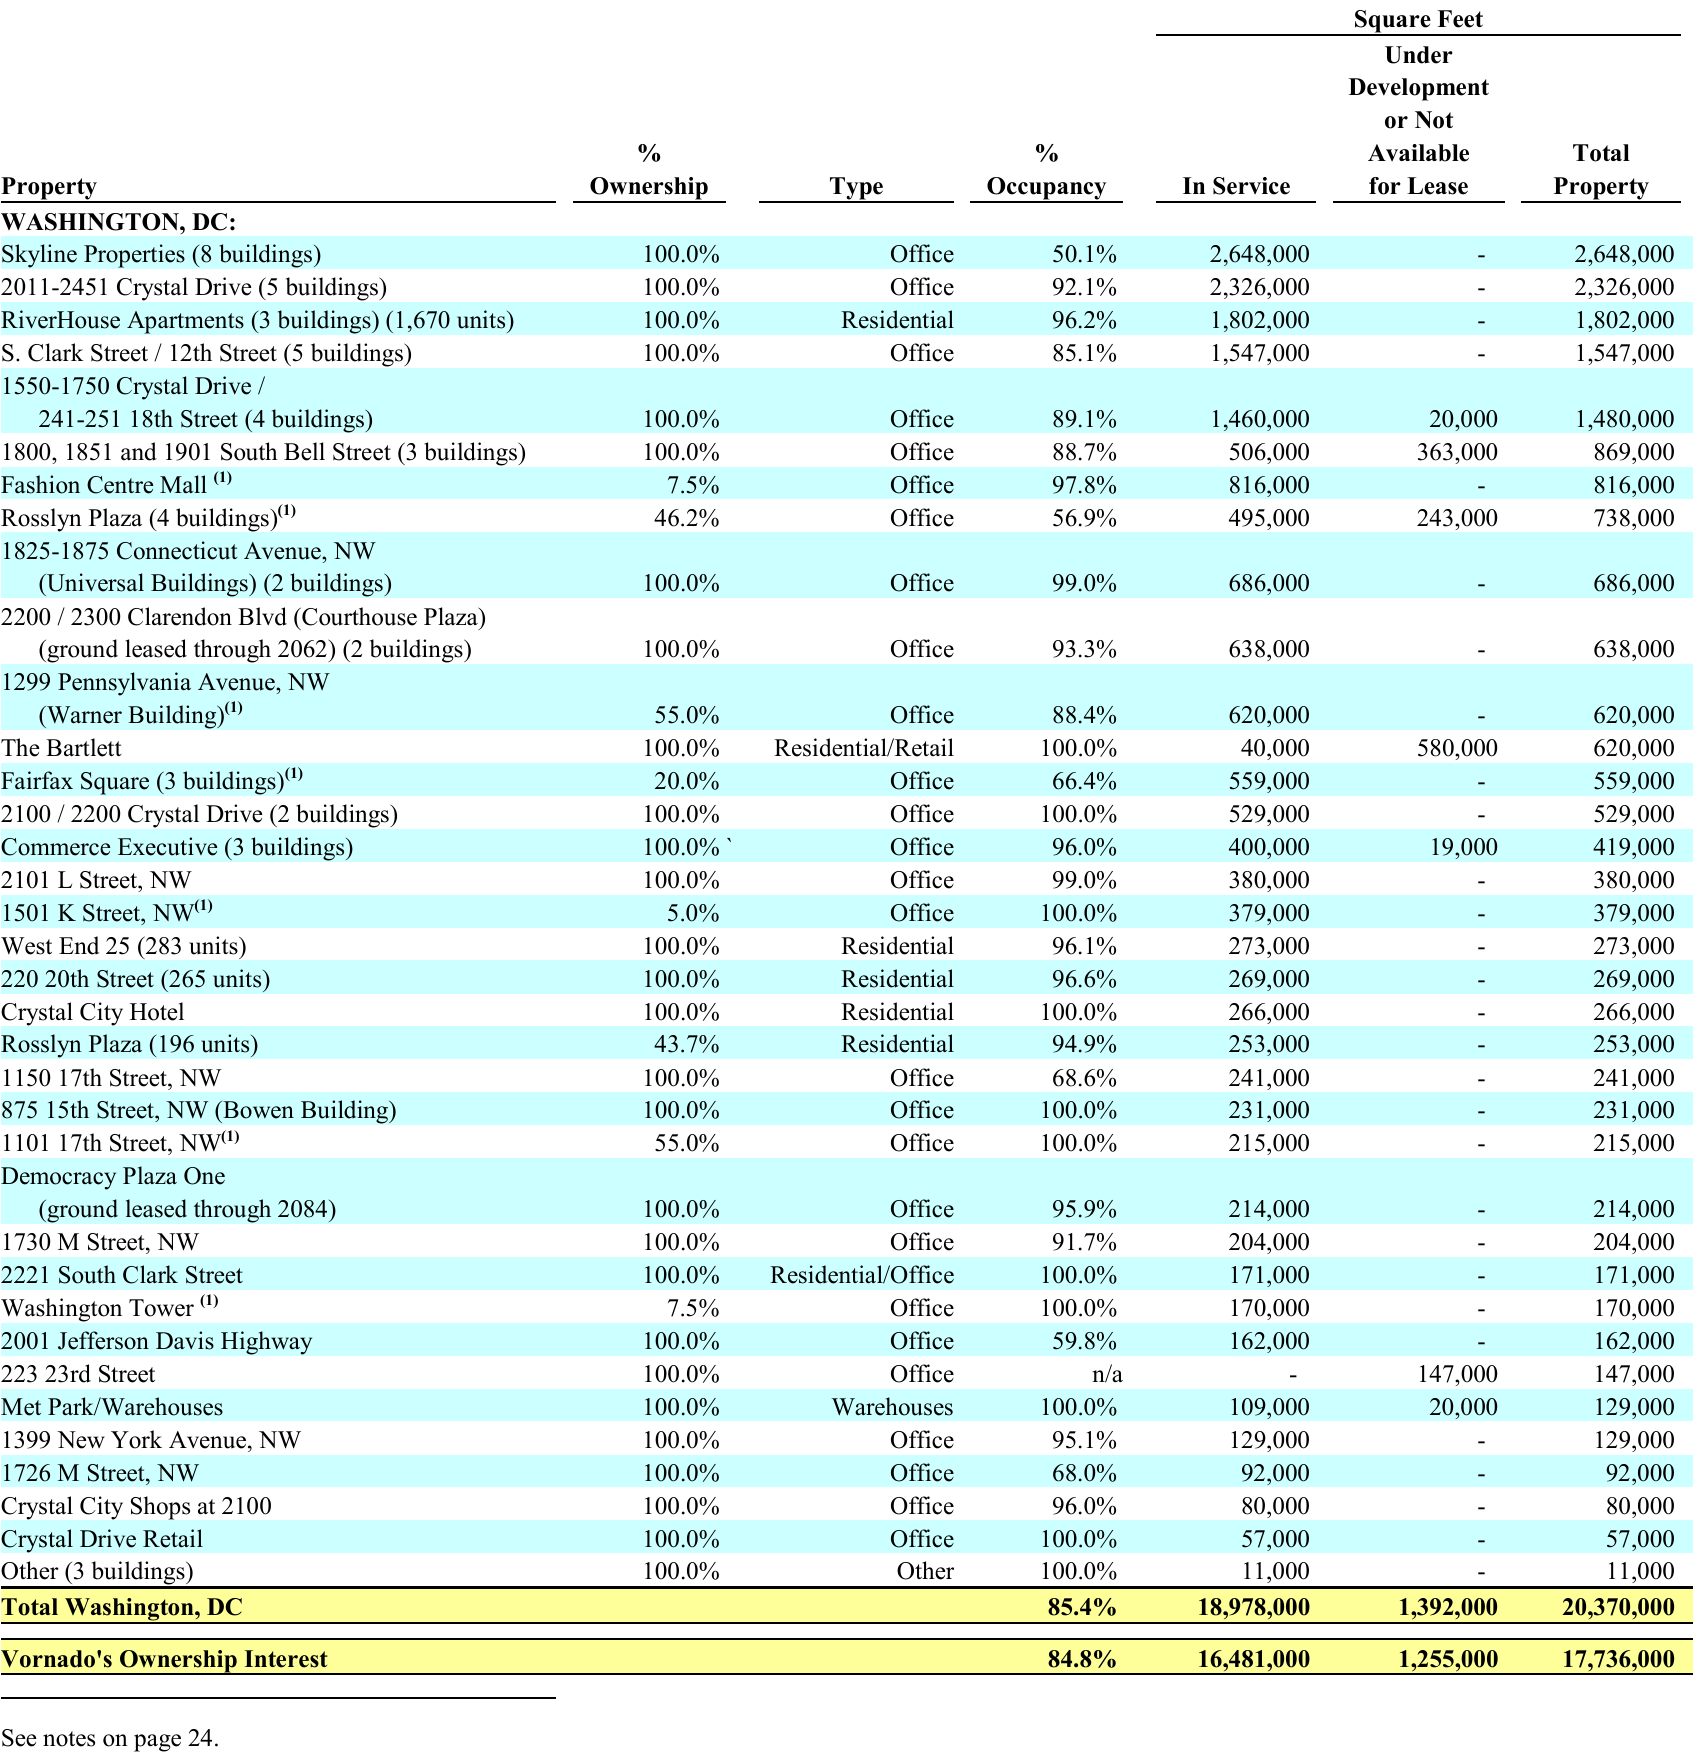

Image ID: fintabnet_050798
Hard score: 54.5
Max colspan: 9
Max rowspan: 1
Number of rows: 69
Image exists: True


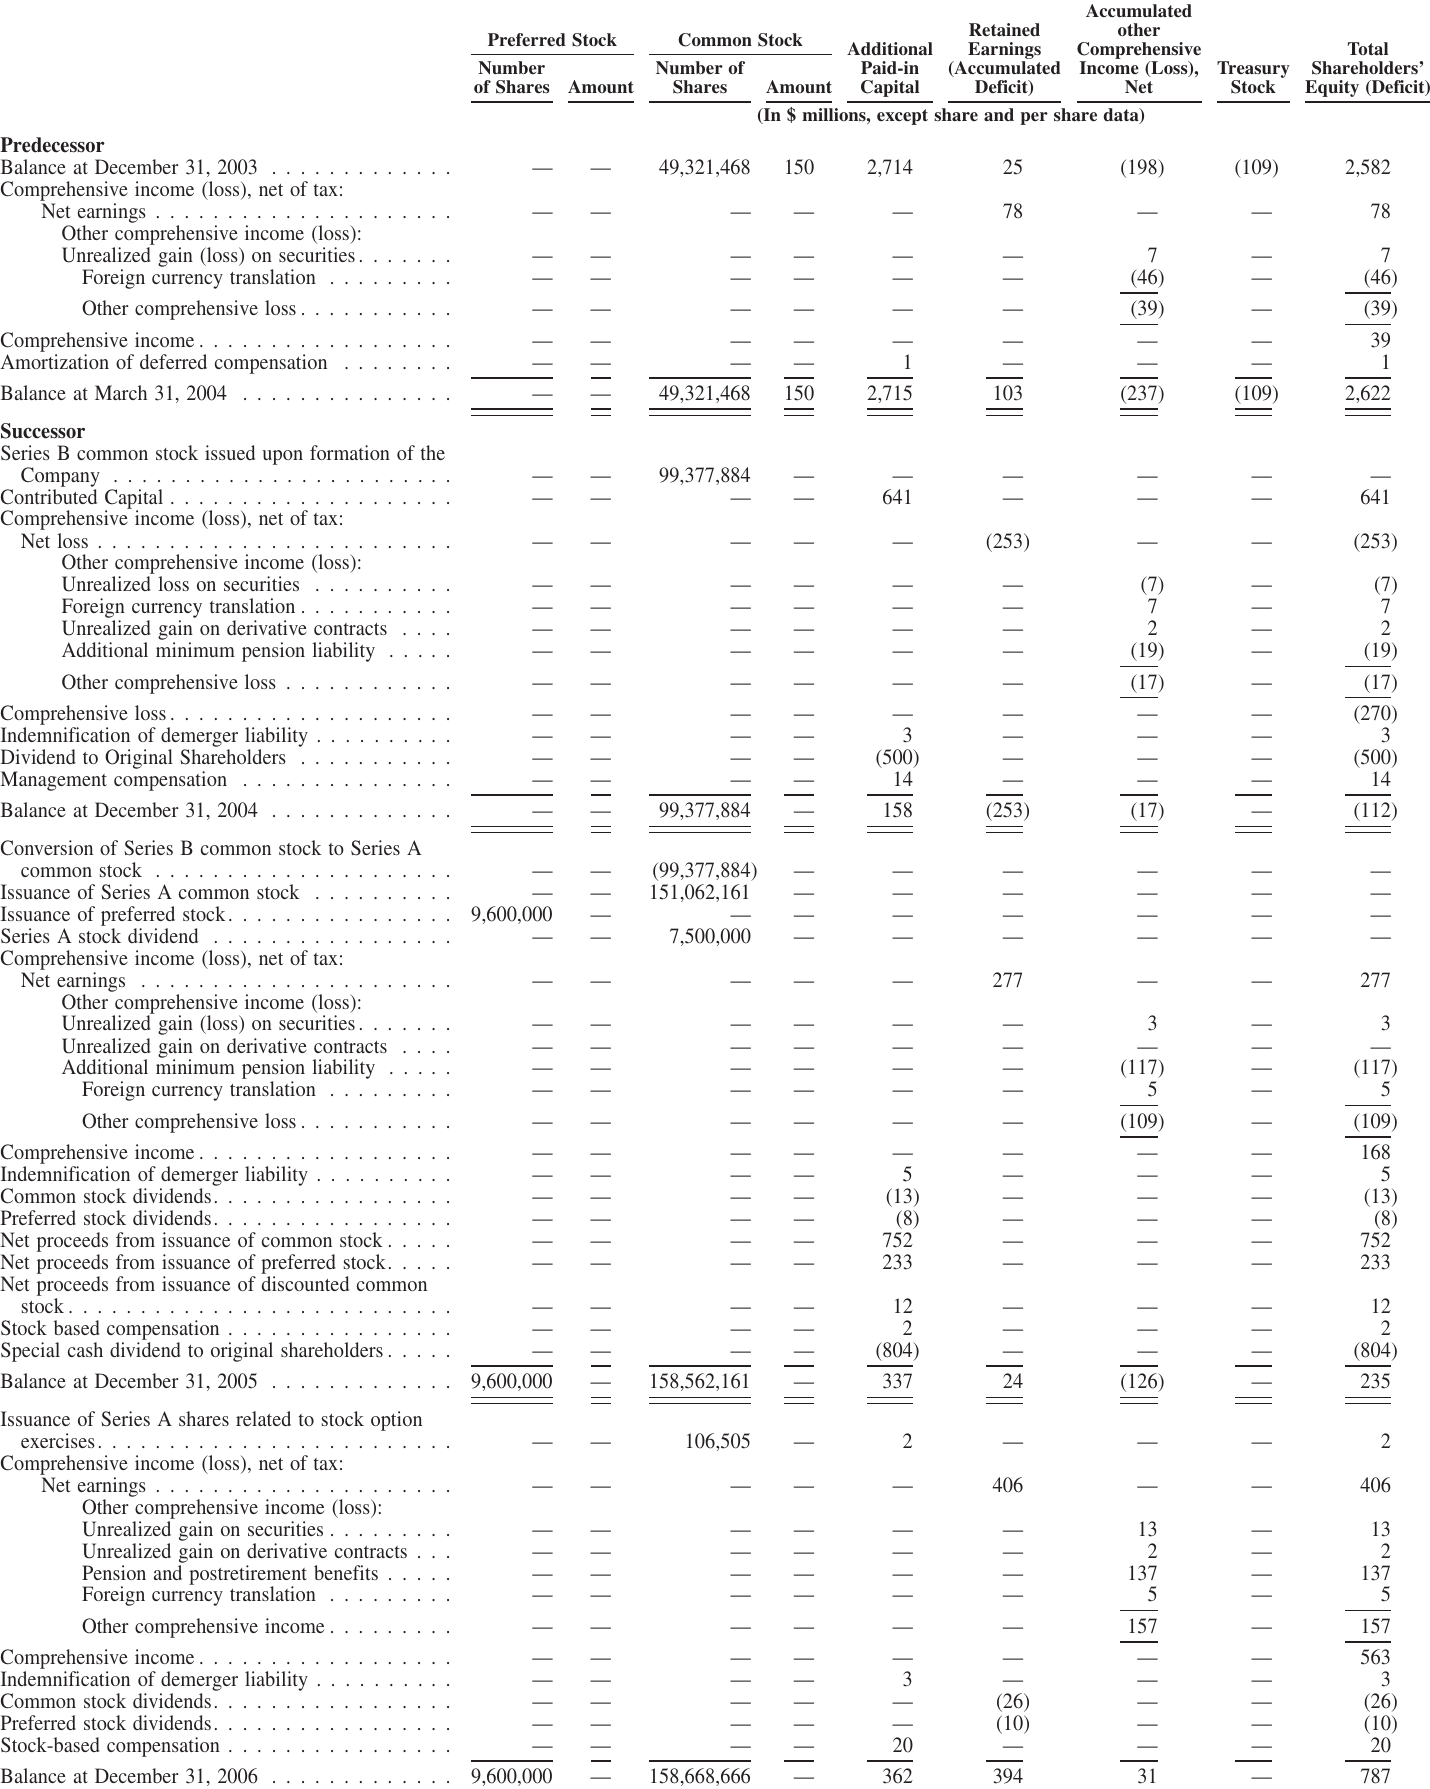

In [23]:
# display the top N hardest examples

top_n = 3
top_examples = hard_examples.head(top_n)

for i, row in top_examples.iterrows():
    img_path = os.path.join(IMAGE_DIR, row["imgid"] + ".png")

    print("=" * 80)
    print("Image ID:", row["imgid"])
    print("Hard score:", row["hard_score"])
    print("Max colspan:", row["max_colspan"])
    print("Max rowspan:", row["max_rowspan"])
    print("Number of rows:", row["num_rows"])
    print("Image exists:", os.path.exists(img_path))

    display(Image.open(img_path))

# Part 2: Image EDA  
- Are the image sizes uniform?  
- Are most of the images wide or long tables?  
- Will the image quality affect the model's recognition?  
- Which images might be considered as hard examples in the visual sense?

## 1. Load image path

In [24]:
import os
import pandas as pd
from PIL import Image

image_files = [
    f for f in os.listdir(IMAGE_DIR)
    if f.endswith(".png")
]

print("Total images:", len(image_files))
image_files[:5]

Total images: 32670


['fintabnet_014007.png',
 'fintabnet_013768.png',
 'fintabnet_023873.png',
 'fintabnet_054423.png',
 'fintabnet_015319.png']

## 2. Extract image size information  
- width  
- height  
- aspect_ratio

In [25]:
# #intial version(No progress bar)
# image_info = []

# for img_file in image_files:
#     img_path = os.path.join(IMAGE_DIR, img_file)
#     img = Image.open(img_path)
#     width, height = img.size

#     image_info.append({
#         "img_file": img_file,
#         "imgid": img_file.replace(".png", ""),
#         "width": width,
#         "height": height,
#         "aspect_ratio": width / height
#     })

# df_images = pd.DataFrame(image_info)
# df_images.head()

KeyboardInterrupt: 

In [26]:
# 进度条版 progress bar
from tqdm.notebook import tqdm  # 导入进度条工具
import os
from PIL import Image
import pandas as pd

image_info = []

# 1. 在循环这里加上 tqdm(...)
# desc 是进度条左侧显示的文字描述
for img_file in tqdm(image_files, desc="提取图片尺寸信息"):

    img_path = os.path.join(IMAGE_DIR, img_file)

    # 建议加上 try-except，防止某张图片损坏导致整个半小时的运行中断
    try:
        img = Image.open(img_path)
        width, height = img.size

        image_info.append({
            "img_file": img_file,
            "imgid": img_file.replace(".png", ""),
            "width": width,
            "height": height,
            "aspect_ratio": width / height
        })
    except Exception as e:
        print(f"无法处理图片 {img_file}: {e}")

# 转换成 DataFrame
df_images = pd.DataFrame(image_info)
df_images.head()

提取图片尺寸信息:   0%|          | 0/32670 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [27]:
# 此cell和下一个cell的代码跟上一个代码的作用一致
# 将文件从 Drive 拷贝到本地 (速度提升)

# ===== Step 1: copy images to local (for speed) =====
import os

LOCAL_IMAGE_DIR = "/content/local_images"
DRIVE_IMAGE_DIR = "/content/drive/MyDrive/cv project/hierarchical_tables_v1/data/processed/images"

# create local folder
!mkdir -p {LOCAL_IMAGE_DIR}

# copy (only run once!)
!cp -r "{DRIVE_IMAGE_DIR}/." {LOCAL_IMAGE_DIR}/

print("Images copied to local disk!")

Images copied to local disk!


In [28]:
# ===== Step 2: list image files =====
import os

IMAGE_DIR = LOCAL_IMAGE_DIR

image_files = os.listdir(IMAGE_DIR)

print("Total images:", len(image_files))
print(image_files[:5])

Total images: 32671
['fintabnet_022825.png', 'fintabnet_028412.png', 'fintabnet_008744.png', 'fintabnet_021043.png', 'fintabnet_048126.png']


In [29]:
# Filter out non-PNG files
extra_files = [f for f in image_files if not f.endswith(".png")]

print("Extra files:", extra_files)
print("Count:", len(extra_files))

Extra files: ['data']
Count: 1


In [30]:
image_files = [f for f in os.listdir(IMAGE_DIR) if f.endswith(".png")]
print("Filtered images:", len(image_files))

Filtered images: 32670


In [32]:
# ===== Step 3: extract image info with progress bar =====
from tqdm.notebook import tqdm
from PIL import Image
import pandas as pd

image_info = []

for img_file in tqdm(image_files, desc="Processing images"):

    img_path = os.path.join(IMAGE_DIR, img_file)

    try:
        with Image.open(img_path) as img:
            width, height = img.size

        image_info.append({
            "img_file": img_file,
            "imgid": img_file.replace(".png", ""),
            "width": width,
            "height": height,
            "aspect_ratio": width / height
        })

    except Exception as e:
        print(f"⚠️ Error with {img_file}: {e}")

# convert to DataFrame
df_images = pd.DataFrame(image_info)

df_images.head()

Processing images:   0%|          | 0/32670 [00:00<?, ?it/s]

⚠️ Error with fintabnet_061523.png: cannot identify image file '/content/local_images/fintabnet_061523.png'


,img_file,imgid,width,height,aspect_ratio
0,fintabnet_022825.png,fintabnet_022825,814,909,0.895490
1,fintabnet_028412.png,fintabnet_028412,1431,433,3.304850
2,fintabnet_008744.png,fintabnet_008744,1595,2006,0.795115
3,fintabnet_021043.png,fintabnet_021043,1224,283,4.325088
4,fintabnet_048126.png,fintabnet_048126,1167,670,1.741791


one image was broken: fintabnet_061523.png

In [45]:
#Manually add the damaged data to maintain the consistency of the total data volume.

missing_row = pd.DataFrame([{
    "img_file": "fintabnet_061523.png",
    "imgid": "fintabnet_061523",
    "width": np.nan,
    "height": np.nan,
    "aspect_ratio": np.nan
}])

df_images = pd.concat([df_images, missing_row], ignore_index=True)

print("New length:", len(df_images))

New length: 32670


### Summary statistics for image size

In [46]:
df_images[["width", "height", "aspect_ratio"]].describe()

,width,height,aspect_ratio
count,32669.000000,32669.000000,32669.000000
mean,1458.128317,661.639597,3.388716
std,223.224194,479.934080,2.213243
min,506.000000,78.000000,0.375893
25%,1406.000000,312.000000,1.687719
50%,1483.000000,489.000000,2.925319
75%,1597.000000,851.000000,4.558559
max,2085.000000,2477.000000,21.426829


The width of the images is generally concentrated around 1400-1600, but the height varies greatly, ranging from 78 to 2477. This indicates that in this dataset, there are both very thin wide tables and very tall long tables.   

The aspect_ratio reaches a maximum of 21.43, indicating the presence of extremely wide tables. Such images are prone to being compressed and distorted when resized for input into the model, which may affect the model's ability to recognize column structures.

### Width distribution

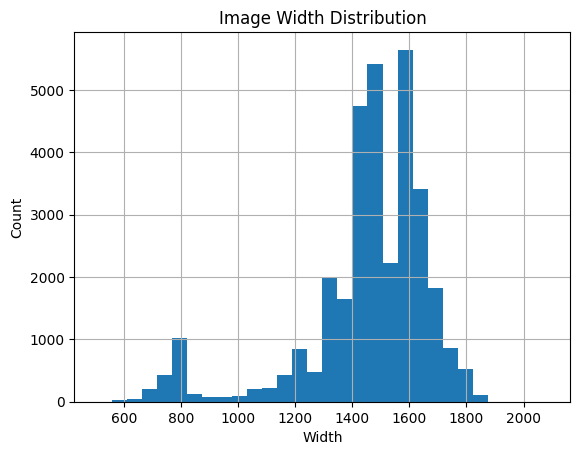

,count,ratio
width_bin,,
"(0, 300]",0,0.000000
"(300, 600]",12,0.000367
"(600, 900]",1885,0.057700
"(900, 1200]",1130,0.034589
"(1200, 1500]",14734,0.451009
"(1500, 2000]",14906,0.456274
"(2000, 3000]",2,0.000061


In [47]:
import matplotlib.pyplot as plt

df_images["width"].hist(bins=30)
plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Count")
plt.show()


# Width distribution (binned)
bins = [0, 300, 600, 900, 1200, 1500, 2000, 3000]
df_images["width_bin"] = pd.cut(df_images["width"], bins=bins)
width_counts = df_images["width_bin"].value_counts().sort_index()
width_ratio = df_images["width_bin"].value_counts(normalize=True).sort_index()
width_dist = pd.DataFrame({
    "count": width_counts,
    "ratio": width_ratio
})

width_dist

Approximately 90.7% of the image widths are concentrated between 1200 and 2000 px. This indicates that the width is relatively stable, and the width differences when the model is resized will not be particularly confusing.  

There are also a few low-width and ultra-wide images.


### Height distribution

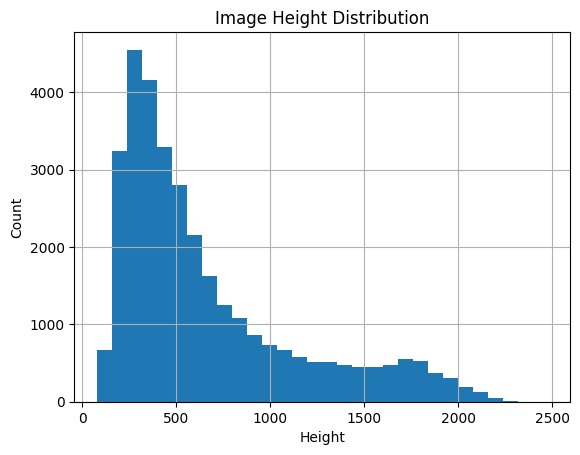

,count,ratio
height_bin,,
"(0, 300]",7468,0.228596
"(300, 600]",12535,0.383697
"(600, 900]",5109,0.156387
"(900, 1200]",2569,0.078637
"(1200, 1600]",2386,0.073036
"(1600, 2000]",2220,0.067954
"(2000, 2600]",382,0.011693


In [48]:
df_images["height"].hist(bins=30)
plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Count")
plt.show()


# Height distribution with manual bins
height_bins = [0, 300, 600, 900, 1200, 1600, 2000, 2600]
df_images["height_bin"] = pd.cut(df_images["height"], bins=height_bins)

height_counts = df_images["height_bin"].value_counts().sort_index()
height_ratio = df_images["height_bin"].value_counts(normalize=True).sort_index()

height_dist = pd.DataFrame({
    "count": height_counts,
    "ratio": height_ratio
})

height_dist

Most of the pictures are not particularly tall, but there is a long-tail distribution, that is, a few pictures are very tall. Tables of very high height may contain many rows, and subsequent models need to handle more visual tokens or patches, resulting in higher computational costs.


## Aspect ratio distribution

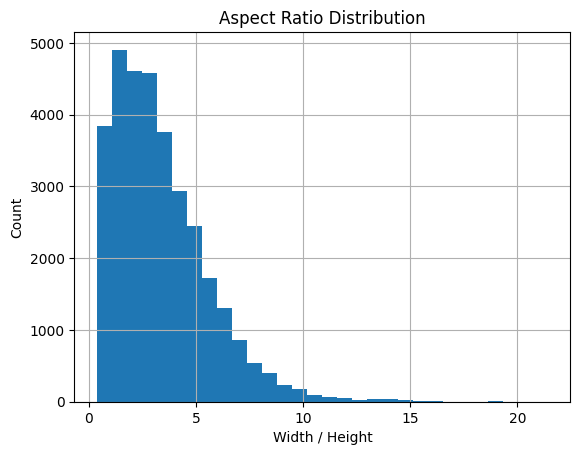

,count,ratio
aspect_ratio_bin,,
"(0, 1]",3189,0.097615
"(1, 2]",7015,0.214730
"(2, 3]",6594,0.201843
"(3, 5]",9324,0.285408
"(5, 8]",5300,0.162233
"(8, 12]",1055,0.032294
"(12, 25]",192,0.005877


In [49]:
df_images["aspect_ratio"].hist(bins=30)
plt.title("Aspect Ratio Distribution")
plt.xlabel("Width / Height")
plt.ylabel("Count")
plt.show()


# Aspect ratio distribution with manual bins
aspect_bins = [0, 1, 2, 3, 5, 8, 12, 25]
df_images["aspect_ratio_bin"] = pd.cut(df_images["aspect_ratio"], bins=aspect_bins)

aspect_counts = df_images["aspect_ratio_bin"].value_counts().sort_index()
aspect_ratio = df_images["aspect_ratio_bin"].value_counts(normalize=True).sort_index()

aspect_ratio_dist = pd.DataFrame({
    "count": aspect_counts,
    "ratio": aspect_ratio
})

aspect_ratio_dist

More than half of the images have an aspect ratio greater than 3, indicating that there are many wide tables in the dataset. Particularly, the two groups of (3, 5] and (5, 10] account for a high proportion.   

The "hard examples" not only involve complex HTML structures, but also have issues related to visual wide tables. **Wide tables may cause resize distortion and also make it more difficult for the model to align columns and headers.**

## 3. Blurriness analysis  
Blur detection using **Laplacian variance**  
- The clearer the image → The more distinct the edges → The greater the gradient change → The higher the variance  
- The more blurry the image → The smoother the edges → The lower the variance

In [42]:
import cv2
import numpy as np

def calculate_blur_score(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    blur_score = cv2.Laplacian(img, cv2.CV_64F).var()
    return blur_score

# blur_scores = []

# for img_file in image_files:
#     img_path = os.path.join(IMAGE_DIR, img_file)
#     blur_scores.append(calculate_blur_score(img_path))

# df_images["blur_score"] = blur_scores
# df_images[["img_file", "blur_score"]].head()

In [51]:
from tqdm.notebook import tqdm
import os

blur_scores = []

for img_file in tqdm(image_files, desc="Calculating blur score"):
    img_path = os.path.join(IMAGE_DIR, img_file)

    try:
        score = calculate_blur_score(img_path)
    except Exception as e:
        print(f"⚠️ Error: {img_file}")
        score = None

    blur_scores.append(score)


df_images["blur_score"] = blur_scores
df_images[["img_file", "blur_score"]].head()

,img_file,blur_score
0,fintabnet_022825.png,6510.479339
1,fintabnet_028412.png,5729.901042
2,fintabnet_008744.png,5399.216423
3,fintabnet_021043.png,5356.808432
4,fintabnet_048126.png,2163.998694


## blur score distribution  
- The higher the score, the clearer the edge;  
- The lower the score, the blurrier the picture

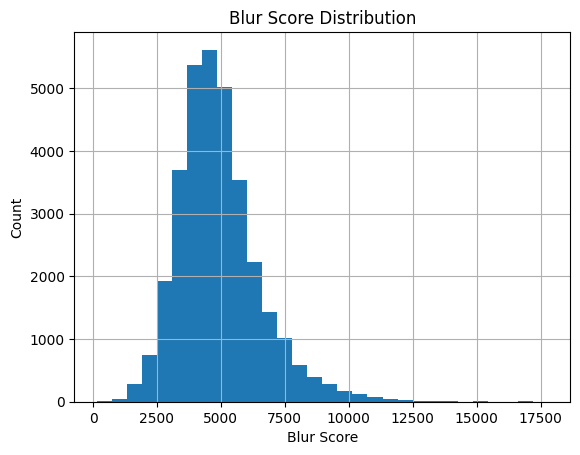

,count,ratio
blur_bin,,
"(0, 1000]",14,0.000429
"(1000, 2000]",399,0.012213
"(2000, 4000]",9206,0.281796
"(4000, 6000]",16488,0.504699
"(6000, 8000]",5040,0.154275
"(8000, 12000]",1451,0.044415
"(12000, 20000]",71,0.002173


In [53]:
df_images["blur_score"].hist(bins=30)
plt.title("Blur Score Distribution")
plt.xlabel("Blur Score")
plt.ylabel("Count")
plt.show()


# Blur score distribution (binned)
bins = [0, 1000, 2000, 4000, 6000, 8000, 12000, 20000]
df_images["blur_bin"] = pd.cut(df_images["blur_score"], bins=bins)

blur_counts = df_images["blur_bin"].value_counts().sort_index()
blur_ratio = df_images["blur_bin"].value_counts(normalize=True).sort_index()

blur_dist = pd.DataFrame({
    "count": blur_counts,
    "ratio": blur_ratio
})

blur_dist

The blur score distribution shows a strong concentration between 2000 and 6000, indicating that most images are clear and contain well-defined edges. Only a very small proportion of images have low blur scores, suggesting that severe blurriness is rare.

**Overall, image quality is generally high, and blur is not a primary factor contributing to difficulty in table structure recognition.**

## 4. Contrast analysis  
Contrast score measures pixel intensity variation; higher values indicate clearer separation between table structures.

In [56]:
# Convert the image to a grayscale image, and then calculate the standard deviation of the pixel values.
def calculate_contrast_score(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    contrast_score = img.std()
    return contrast_score

# Calculate the contrast of all the pictures
contrast_scores = []

for img_file in tqdm(image_files, desc="Calculating contrast score"):
    img_path = os.path.join(IMAGE_DIR, img_file)

    try:
        score = calculate_contrast_score(img_path)
    except:
        score = np.nan

    contrast_scores.append(score)

df_contrast = pd.DataFrame({
    "img_file": image_files,
    "contrast_score": contrast_scores
    })

df_images = df_images.merge(df_contrast, on="img_file", how="left")
df_images[["img_file", "contrast_score"]].head()

Calculating contrast score:   0%|          | 0/32670 [00:00<?, ?it/s]

,img_file,contrast_score
0,fintabnet_022825.png,46.854336
1,fintabnet_028412.png,52.939160
2,fintabnet_008744.png,55.280977
3,fintabnet_021043.png,45.197025
4,fintabnet_048126.png,30.298362


## contrast score distribution  


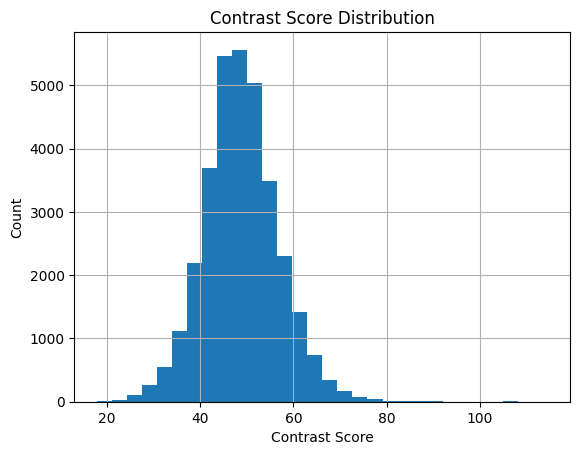

,count,ratio
contrast_bin,,
"(0, 20]",3,0.000092
"(20, 40]",3913,0.119821
"(40, 50]",14925,0.457023
"(50, 60]",11114,0.340325
"(60, 70]",2406,0.073675
"(70, 80]",252,0.007717
"(80, 100]",44,0.001347


In [57]:
df_images["contrast_score"].hist(bins=30)
plt.title("Contrast Score Distribution")
plt.xlabel("Contrast Score")
plt.ylabel("Count")
plt.show()


# Contrast score distribution with manual bins
contrast_bins = [0, 20, 40, 50, 60, 70, 80, 100]
df_images["contrast_bin"] = pd.cut(df_images["contrast_score"], bins=contrast_bins)

contrast_counts = df_images["contrast_bin"].value_counts().sort_index()
contrast_ratio = df_images["contrast_bin"].value_counts(normalize=True).sort_index()

contrast_dist = pd.DataFrame({
    "count": contrast_counts,
    "ratio": contrast_ratio
})

contrast_dist

The contrast score distribution shows a strong concentration between 40 and 60, with nearly 80% of images falling within this range. This indicates that most images have well-balanced brightness and clear structural boundaries. Extremely low or high contrast cases are rare, suggesting that image contrast is generally consistent across the dataset and is unlikely to be a major source of difficulty.  

Compared to blur, contrast shows a tighter distribution, indicating that contrast is even less likely to be a major source of difficulty.

## 6. Image categorization  
**wide_table > tall_table > blur > contrast > normal**  
The categorization prioritizes layout-based features (e.g., wide and tall tables) because structural complexity is the primary challenge in table recognition. Image quality factors such as blur and contrast are considered afterward, as they affect visual clarity but are less dominant in this dataset.

In [58]:
def categorize_image(row):
    if row["aspect_ratio"] > 3:
        return "wide_table"
    elif row["height"] > 1500:
        return "tall_table"
    elif row["blur_score"] < df_images["blur_score"].quantile(0.1):
        return "low_quality_blur"
    elif row["contrast_score"] < df_images["contrast_score"].quantile(0.1):
        return "low_contrast"
    else:
        return "normal_table"

df_images["image_type"] = df_images.apply(categorize_image, axis=1)

df_images["image_type"].value_counts()

,count
image_type,
wide_table,15871
normal_table,11371
tall_table,3168
low_quality_blur,1320
low_contrast,940


Image categorization shows that wide tables dominate the dataset, accounting for nearly half of all samples. In contrast, low-quality images with blur or low contrast form only a small proportion. This indicates that the primary challenge in the dataset arises from structural and layout complexity rather than image quality issues.

## 9. Display sample images by category (verification)  
verify if the image categories align with their intended definitions.

In [59]:
for image_type in df_images["image_type"].unique():
    sample = df_images[df_images["image_type"] == image_type].iloc[0]
    img_path = os.path.join(IMAGE_DIR, sample["img_file"])

    print("=" * 80)
    print("Image type:", image_type)
    print("Image file:", sample["img_file"])
    print("Width:", sample["width"])
    print("Height:", sample["height"])
    print("Aspect ratio:", sample["aspect_ratio"])
    print("Blur score:", sample["blur_score"])
    print("Contrast score:", sample["contrast_score"])

    display(Image.open(img_path))

Output hidden; open in https://colab.research.google.com to view.

- The wide_table category correctly captures horizontally extended tables with many columns.  
- Tall tables contain a large number of rows, leading to vertically elongated structures.  
- Blurry images show weak edges, which may hinder accurate structure detection.  
- Low-contrast images have weak intensity differences, making cell boundaries less distinguishable.  
- Normal tables exhibit balanced size and good visual quality.

## Part 3: Merge image-level features with HTML structural features

In [60]:
df_combined = df_features.merge(df_images, on="imgid", how="left")

df_combined.head()

,num_rows,num_cells,max_colspan,max_rowspan,has_colspan,has_rowspan,is_complex,hard_score,imgid,img_file,...,height,aspect_ratio,width_bin,height_bin,aspect_ratio_bin,blur_score,blur_bin,contrast_score,contrast_bin,image_type
0,9,34,3,1,True,False,True,12.5,fintabnet_000001,fintabnet_000001.png,...,464.0,3.127155,"(1200, 1500]","(300, 600]","(3, 5]",3678.917551,"(2000, 4000]",43.968108,"(40, 50]",wide_table
1,40,158,3,1,True,False,True,28.0,fintabnet_000004,fintabnet_000004.png,...,1826.0,0.795181,"(1200, 1500]","(1600, 2000]","(0, 1]",2894.365766,"(2000, 4000]",38.080415,"(20, 40]",tall_table
2,6,55,2,2,True,True,True,11.0,fintabnet_000006,fintabnet_000006.png,...,366.0,4.144809,"(1500, 2000]","(300, 600]","(3, 5]",6247.870952,"(6000, 8000]",55.573495,"(50, 60]",wide_table
3,7,26,3,1,True,False,True,11.5,fintabnet_000007,fintabnet_000007.png,...,330.0,4.015152,"(1200, 1500]","(300, 600]","(3, 5]",4598.369386,"(4000, 6000]",51.369766,"(50, 60]",wide_table
4,12,46,2,2,True,True,True,14.0,fintabnet_000008,fintabnet_000008.png,...,527.0,2.755218,"(1200, 1500]","(300, 600]","(2, 3]",7751.798653,"(6000, 8000]",38.023786,"(20, 40]",low_contrast


## Complex structure vs. image type

In [61]:
df_combined.groupby("image_type")["max_colspan"].mean()

,max_colspan
image_type,
low_contrast,3.555319
low_quality_blur,3.343182
normal_table,3.622197
tall_table,3.310922
wide_table,3.295066


Wide tables are visually wide but do not necessarily have large colspan values.  
Because wide tables are defined by aspect_ratio>3, which is the visual wide. While the colspan is defined by html structure

## In which types are hard examples distributed

In [62]:
df_combined.sort_values("hard_score", ascending=False).head(20)["image_type"]

,image_type
14650,wide_table
32506,tall_table
27077,tall_table
31019,tall_table
32485,tall_table
3450,tall_table
3512,tall_table
30965,tall_table
30633,tall_table
30666,tall_table


Hard examples are dominated by tall tables because the scoring function (Part1 - 6. Filter hard examples) gives more weights on row count. metric bias  

hard_score =
    colspan * 2 +
    rowspan * 2 +
    num_rows * 0.5

## Complex structure vs. image size

In [63]:

df_combined[["num_rows", "width", "height"]].corr()

,num_rows,width,height
num_rows,1.000000,0.177607,0.909327
width,0.177607,1.000000,0.192205
height,0.909327,0.192205,1.000000


The number of rows is highly correlated with image height.

## Quality vs. structure

In [64]:

df_combined.groupby("image_type")["hard_score"].mean()

,hard_score
image_type,
low_contrast,19.363830
low_quality_blur,18.089394
normal_table,18.528406
tall_table,28.664615
wide_table,12.528322


Wide tables are structurally complex in columns but not in rows, leading to lower hard_score.

# **Summary**  

1. The findings from html EDA and image EDA are consistent:  
HTML complexity is driven by colspan/rowspan, while image complexity is dominated by wide table layouts.  

2. Table difficulty is multi-dimensional, involving both **structural complexity (row-wise)** and **visual layout complexity (column-wise)**.  
- **HTML structure difficulty (defined by ourself)**  
→ Led by num_rows  
→ tall_table is the most difficult  

- **Visual Layout Difficulty (image EDA)**  
→ Dominated by aspect_ratio  
→ It is very difficult for wide_table

## Part 4: TEDS (Tree-Edit-Distance) calculation  
TEDS measures the structural similarity between predicted and ground truth HTML tables by comparing their tree representations.

HTML → DOM Tree → Tree Edit Distance → Similarity score  

- The function represents HTML tables as tree structures and computes similarity using tree edit distance. This approach captures hierarchical relationships and structural differences more accurately, making it more suitable for evaluating table structure recognition models.  

- The tree-based formulation allows the metric to account for insertions, deletions, and structural mismatches, providing a more robust evaluation than sequence-based methods.  

- TEDS is a similarity ranging from 0 to 1.  
A higher TEDS indicates better structural alignment, while a lower score suggests significant differences.  

In [ ]:
# initial draft
# simplified version: compares the consistency tag sequences

# from bs4 import BeautifulSoup

# def extract_tags(html):
#   """
#   Convert HTML into a "tag sequence"

#   for example:
#   <table>
#     <tr>
#       <td>A</td>
#       <td>B</td>
#     </tr>
#   </table>

#   will be converted to
#   ['table', 'tr', 'td', 'td']
#   """
#   soup = BeautifulSoup(html, "html.parser")

#   return [tag.name for tag in soup.find_all()]


# def simple_teds(pred_html, true_html):
#     # Obtain the structures of pred and true
#     pred_tags = extract_tags(pred_html)
#     true_tags = extract_tags(true_html)

#     # Align the length (avoid out-of-bounds)：If the HTML lengths of "pred" and "true" are different, only the parts with the same lengths at the beginning will be compared.
#     min_len = min(len(pred_tags), len(true_tags))

#     # Compare positions one by one and count the correct number
#     match = sum(pred_tags[i] == true_tags[i] for i in range(min_len))

#     return match / max(len(true_tags), 1)

In [66]:
!pip install zss

  Preparing metadata (setup.py) ... done
  Created wheel for zss: filename=zss-1.2.0-py3-none-any.whl size=6725 sha256=3f35851dcbafbe62deb8cfffc451ef0f7ff06cf8e3813bafac03f076cf91c107
  Stored in directory: /root/.cache/pip/wheels/46/e7/2e/44fb39352ad468427a7528cacbefefaa438a898dfd1ad2eaa4
Successfully built zss


### Convert HTML into a tree structure

In [67]:
from bs4 import BeautifulSoup
from zss import Node

def build_tree(html):
    soup = BeautifulSoup(html, "html.parser")

    def convert(tag):
        if not hasattr(tag, "name") or tag.name is None:
            return None

        node = Node(tag.name)

        for child in tag.children:
            child_node = convert(child)
            if child_node:
                node.addkid(child_node)

        return node

    # Find the table as root (very important)
    table = soup.find("table")
    return convert(table)

### Define Tree Edit Distance  
distance = the minimum number of edit operations (insert, delete, replace) needed to transform one HTML tree into another.   



In [68]:
from zss import simple_distance

def tree_edit_distance(html1, html2):
    tree1 = build_tree(html1)
    tree2 = build_tree(html2)

    return simple_distance(tree1, tree2)

### Convert to TEDS score (normalized)  
TEDS is a similarity ranging from 0 to 1

In [69]:
def tree_size(node):
    return 1 + sum(tree_size(child) for child in node.children)

def compute_teds(html1, html2):
    tree1 = build_tree(html1)
    tree2 = build_tree(html2)

    distance = simple_distance(tree1, tree2)

    size = tree_size(tree1) + tree_size(tree2)

    teds = 1 - distance / size

    return max(0, teds)

### Sample test

In [70]:
# test
html1 = records[0]["html_table"]
html2 = records[1]["html_table"]

print("the similarity of different table:",compute_teds(html1, html2))
print("the similarity of the same table:", compute_teds(html1, html1))
print("the similarity of similar but different tables:", compute_teds(records[0]["html_table"], records[2]["html_table"]))

the similarity of different table: 0
the similarity of the same table: 1.0
the similarity of similar but different tables: 0.4036697247706422


The implementation was validated using three cases: identical tables (TEDS = 1), dissimilar tables (TEDS ≈ 0), and partially similar tables (TEDS ≈ 0.4), confirming that the metric behaves as expected.

In [71]:
# sample 50 pairs
scores = []
for i in range(50):
    s = compute_teds(records[i]["html_table"], records[i+1]["html_table"])
    scores.append(s)

pd.Series(scores).describe()

,0
count,50.000000
mean,0.309208
std,0.265127
min,0.000000
25%,0.000000
50%,0.274725
75%,0.506779
max,0.880952


In [72]:
# export df_combined
df_combined.to_csv("/content/drive/MyDrive/cv project/df_combined.csv", index=False)

In [ ]:
# Convert to HTML
!jupyter nbconvert --to html "/content/drive/MyDrive/cv project/week1_eda+teds.ipynb"